#Data Import


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!kaggle datasets download -d ahluwaliasaksham/car-insurance-fraud-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/ahluwaliasaksham/car-insurance-fraud-detection-dataset
License(s): MIT
100% 1.20M/1.20M [00:00<00:00, 125MB/s]



In [ ]:
!unzip car-insurance-fraud-detection-dataset.zip

Archive:  car-insurance-fraud-detection-dataset.zip
  inflating: car_insurance_fraud_dataset.csv  


In [ ]:
!mkdir -p "/content/drive/MyDrive/Vehicle_Insurance_Project"

In [ ]:
!cp fraud_oracle.csv "/content/drive/MyDrive/Vehicle_Insurance_Project/"

cp: cannot stat 'fraud_oracle.csv': No such file or directory


#EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv("/content/car_insurance_fraud_dataset.csv")

In [ ]:
df.head(10)

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N
5,POL100005,PA,700,1015.60,32,MALE,College,Manager,camping,2025-03-11,...,FL,Bethfort,20,2,4,5,No,12483.84,11780.94,N
6,POL100006,PA,300,1254.39,30,OTHER,High School,Doctor,reading,2024-12-26,...,PA,Masonport,16,4,0,3,Yes,16687.40,19045.75,N
7,POL100007,MI,700,1288.08,29,FEMALE,PhD,Lawyer,reading,2025-10-19,...,MI,North Randytown,5,1,3,5,No,7111.40,8272.63,N
8,POL100008,NC,500,942.22,61,FEMALE,College,Clerk,yachting,2023-11-19,...,NC,Jerryberg,22,1,4,5,Yes,1603.74,2549.55,N
9,POL100009,GA,700,1277.15,19,OTHER,High School,Doctor,chess,2024-05-07,...,FL,Newtonshire,17,3,3,0,No,18778.37,15959.84,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [ ]:
df.shape

(30000, 24)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['fraud_reported'].value_counts()

,count
fraud_reported,
N,26560
Y,3440


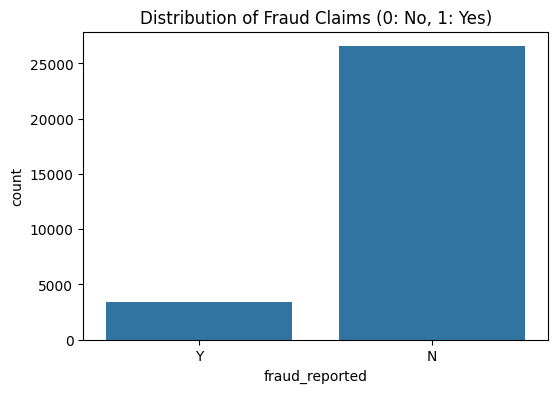

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_reported', data=df)
plt.title('Distribution of Fraud Claims (0: No, 1: Yes)')
plt.show()

print(df['fraud_reported'].value_counts())

In [ ]:
df.describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


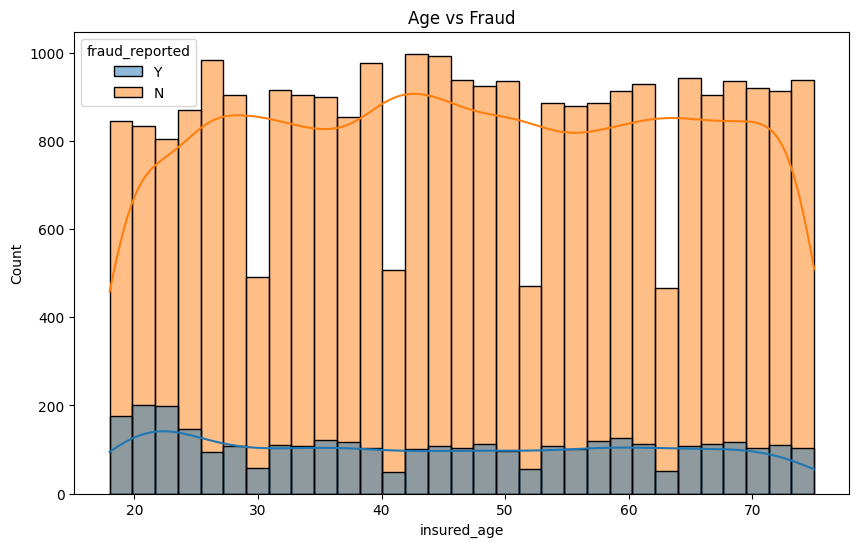

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='insured_age', hue='fraud_reported', kde=True)
plt.title('Age vs Fraud')
plt.show()

In [ ]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')

print(df.isnull().sum().sum())

0


#Data Preprocessing

In [ ]:
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['incident_month'] = df['incident_date'].dt.month
df['incident_day'] = df['incident_date'].dt.day

df.drop(['incident_date', 'policy_id'], axis=1, inplace=True)

In [ ]:
df.columns.tolist()

['policy_state',
 'policy_deductible',
 'policy_annual_premium',
 'insured_age',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'claim_amount',
 'total_claim_amount',
 'fraud_reported',
 'incident_month',
 'incident_day']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,incident_month,incident_day
0,2,400,1430.78,74,2,1,4,5,1,0,...,6,1,4,0,1,8161.36,11677.60,1,6,13
1,8,300,854.49,74,1,0,3,1,3,1,...,0,3,4,5,0,18561.79,18027.81,0,3,23
2,4,400,1247.28,28,2,3,1,5,1,3,...,14,4,4,1,0,10734.61,10375.59,0,1,26
3,0,600,622.42,37,1,3,6,6,1,1,...,22,3,3,5,0,13188.92,14204.34,0,6,3
4,4,700,1458.17,31,2,3,5,5,2,2,...,18,4,2,4,0,21864.69,24038.84,0,5,21


In [ ]:
cols_to_drop = ['policy_id']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [ ]:
y = df['fraud_reported']
X = df.drop('fraud_reported', axis=1)

#Model Training

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.89
Decision Tree: Accuracy = 0.81
Random Forest: Accuracy = 0.89
SVM: Accuracy = 0.89
KNN: Accuracy = 0.87
Naive Bayes: Accuracy = 0.89
Gradient Boosting: Accuracy = 0.88


In [ ]:
final_results = [
    {"Model": "Logistic Regression", "Accuracy": 0.89},
    {"Model": "Decision Tree", "Accuracy": 0.81},
    {"Model": "Random Forest", "Accuracy": 0.88},
    {"Model": "SVM", "Accuracy": 0.89},
    {"Model": "KNN", "Accuracy": 0.87},
    {"Model": "Naive Bayes", "Accuracy": 0.89},
    {"Model": "Gradient Boosting", "Accuracy": 0.88}
]

results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy
Logistic Regression      0.89
        Naive Bayes      0.89
                SVM      0.89
  Gradient Boosting      0.88
      Random Forest      0.88
                KNN      0.87
      Decision Tree      0.81


/tmp/ipykernel_21375/2467657746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


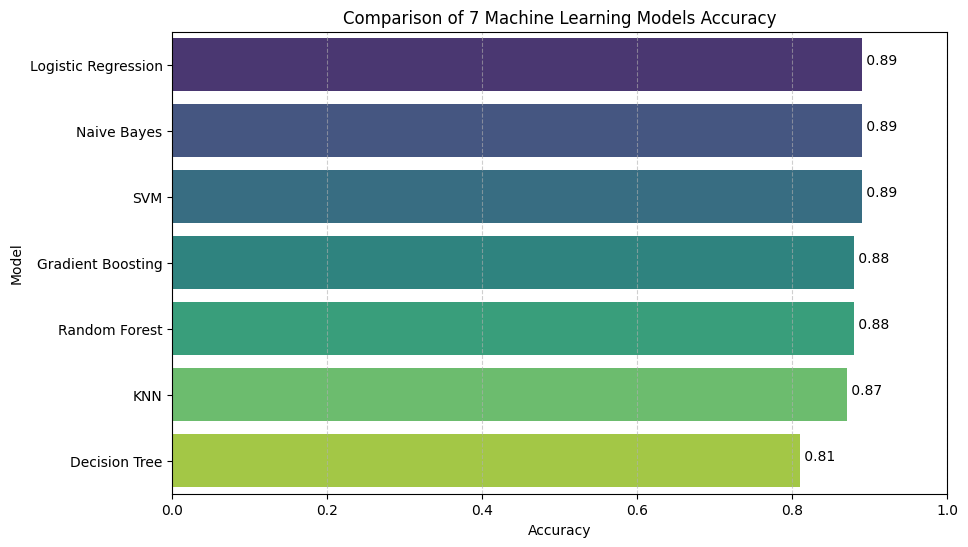

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Comparison of 7 Machine Learning Models Accuracy')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for index, value in enumerate(results_df['Accuracy']):
    plt.text(value, index, f' {value:.2f}')

plt.show()

#Model Evaluation


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


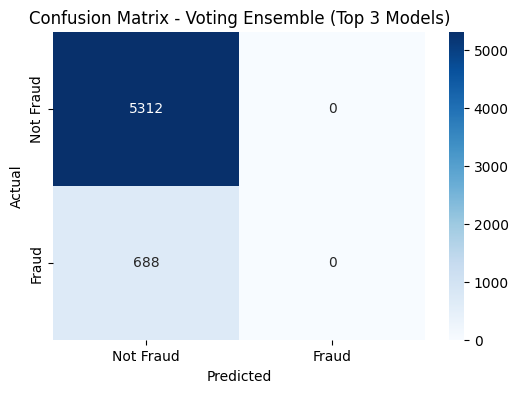

Classification Report for Voting Ensemble:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.00      0.00      0.00       688

    accuracy                           0.89      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.78      0.89      0.83      6000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report


clf1 = models["SVM"]
clf2 = models["Logistic Regression"]
clf3 = models["Naive Bayes"]


best_model = VotingClassifier(
    estimators=[('svm', clf1), ('lr', clf2), ('nb', clf3)],
    voting='hard'
)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Voting Ensemble (Top 3 Models)')
plt.show()

print("Classification Report for Voting Ensemble:")
print(classification_report(y_test, y_pred_best))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


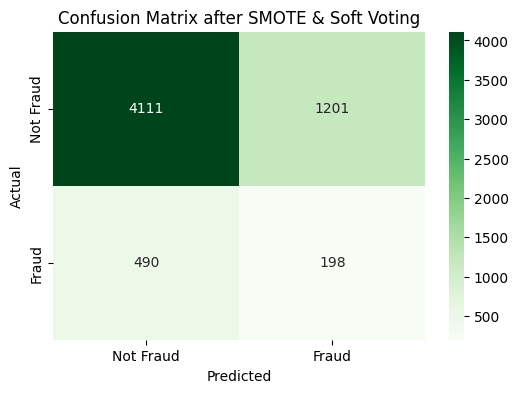

Classification Report after SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      5312
           1       0.14      0.29      0.19       688

    accuracy                           0.72      6000
   macro avg       0.52      0.53      0.51      6000
weighted avg       0.81      0.72      0.76      6000



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

clf1 = models["SVM"]
clf2 = models["Logistic Regression"]
clf3 = models["Naive Bayes"]

from sklearn.svm import SVC
clf1 = SVC(probability=True, random_state=42)

best_model_balanced = VotingClassifier(
    estimators=[('svm', clf1), ('lr', clf2), ('nb', clf3)],
    voting='soft'
)

best_model_balanced.fit(X_train_res, y_train_res)

y_pred_balanced = best_model_balanced.predict(X_test)

plt.figure(figsize=(6, 4))
cm_res = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after SMOTE & Soft Voting')
plt.show()

print("Classification Report after SMOTE:")
print(classification_report(y_test, y_pred_balanced))

ROC-AUC Score: 0.5553


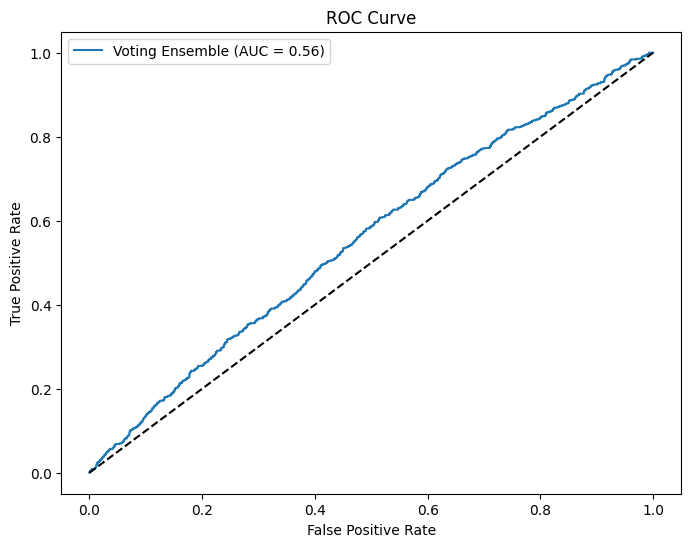

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba = best_model_balanced.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Voting Ensemble (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(best_model_balanced, X_train_res, y_train_res, cv=5, scoring='accuracy')

print("--- نتائج الـ Cross-Validation (5 Folds) ---")
print(f"Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

--- نتائج الـ Cross-Validation (5 Folds) ---
Scores: [0.636      0.80315331 0.81468408 0.80327097 0.80774209]
Mean Accuracy: 0.7730
Standard Deviation: 0.0686


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:07:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


New ROC-AUC Score: 0.7476


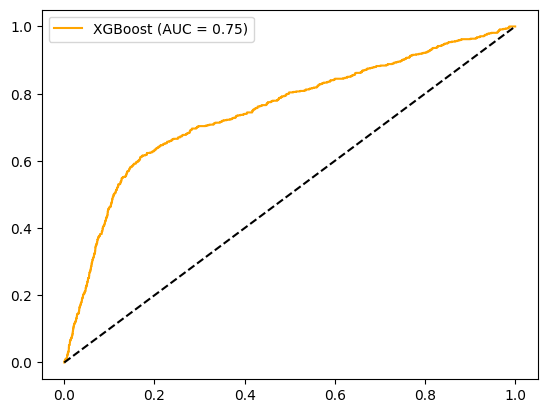

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

new_auc = roc_auc_score(y_test, y_proba_xgb)
print(f"New ROC-AUC Score: {new_auc:.4f}")


fpr_new, tpr_new, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_new, tpr_new, label=f'XGBoost (AUC = {new_auc:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()

#Model Saving


In [ ]:
import pickle

with open('best_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

#Fast API Backend

In [ ]:
from fastapi import FastAPI
import pickle
import pandas as pd
from pydantic import BaseModel
from typing import Dict

app = FastAPI(title="Vehicle Insurance Fraud Detection API")

with open('best_fraud_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('model_columns.pkl', 'rb') as f:
    model_columns = pickle.load(f)


class ClaimData(BaseModel):
    features: Dict[str, float]

@app.get("/")
def home():
    return {"status": "Online", "message": "Fraud Detection API is running"}

@app.post("/predict")
def predict(data: ClaimData):

    input_df = pd.DataFrame([data.features])

    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return {
        "is_fraud": int(prediction),
        "confidence": round(float(probability), 4),
        "result": "Fraudulent Claim ⚠️" if prediction == 1 else "Legitimate Claim ✅"
    }